# CS4350/7350 - Big Data Analytics  
## Phase 2 Starter Notebook: Spark ML Pipeline (Jigsaw Toxic Comment Dataset)

### Purpose
This notebook uses the **Jigsaw Toxic Comment Classification Challenge** training data with **Apache Spark (PySpark) and Spark ML Pipelines**.

### Important
- You must use:
  - **Spark DataFrames**
  - **Spark MLlib**
  - **Spark ML Pipelines**
- Using only `pandas`, `scikit-learn`, or non-Spark ML code does **not** satisfy the project requirements.

### What you still must complete
You are expected to:
1. Download the Kaggle Jigsaw toxic comment data
2. Run the notebook using Spark
3. Review and improve comments where needed
4. Verify all required metrics
5. Add interpretation and discussion
6. Write the 3-4 page report


## Environment Setup

Recommended options:
1. **Databricks Community Edition**
2. **Local PySpark installation**

This notebook expects the Kaggle competition training file from:  
https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge/data

Download `train.csv.zip` from Kaggle and place it in this notebook directory, or extract it and place `train.csv` here. The code below will use `train.csv` directly or extract it from `train.csv.zip` if needed.


In [1]:
# If PySpark is missing, run this once in a notebook cell:
# %pip install pyspark


In [2]:
# Local Kaggle file names.
DATA_PATH = "data/train.csv"

# Databricks example after uploading the CSV:
# DATA_PATH = "/FileStore/tables/train.csv"


In [ ]:
# sets JAVA_HOME for Spark to work properly on macOS with Java 21
import os
os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-21.jdk/Contents/Home"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier,
    LinearSVC,
    NaiveBayes
)

# Start Spark
spark = SparkSession.builder.appName("CS4350_7350_Phase2_Toxic_Comments").getOrCreate()
spark


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/29 15:52:35 WARN Utils: Your hostname, Diegos-MacBook-Pro-2.local, resolves to a loopback address: 127.0.0.1; using 100.70.76.86 instead (on interface en0)
26/04/29 15:52:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/29 15:52:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1. Load the Dataset into a Spark DataFrame

The project requires the use of a **Spark DataFrame**, not a pandas DataFrame.

The Kaggle training file contains the text column `comment_text` plus six binary toxicity labels:
`toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, and `identity_hate`.

For this Spark ML starter workflow, we create one binary target named `label`: 1 if any toxicity column is positive, otherwise 0.


In [ ]:
# Extract train.csv locally
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Download train.csv.zip from Kaggle and place it in this folder."
    )

# Load the Jigsaw toxic comment training data.
raw_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("escape", '"')
    .csv(DATA_PATH)
)

toxic_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# Keep the text and create a single binary target for Spark binary classifiers.
df = (
    raw_df
    .select("id", "comment_text", *toxic_cols)
    .dropna(subset=["comment_text"])
    .withColumn(
        "label",
        (
            F.col("toxic").cast("int")
            + F.col("severe_toxic").cast("int")
            + F.col("obscene").cast("int")
            + F.col("threat").cast("int")
            + F.col("insult").cast("int")
            + F.col("identity_hate").cast("int")
            > 0
        ).cast("double")
    )
)
#df = df.sample(fraction=0.2, seed=42) # Sample 20% of the data for faster experimentation. REMOVE BEOFRE SUBMISSION!
print("Row count:", df.count())
print("Column count:", len(df.columns))
df.printSchema()
df.select("id", "comment_text", "label", *toxic_cols).show(5, truncate=80)


Sampled row count: 32088
Row count: 32088
Column count: 9
root
 |-- id: string (nullable = true)
 |-- comment_text: string (nullable = true)
 |-- toxic: integer (nullable = true)
 |-- severe_toxic: integer (nullable = true)
 |-- obscene: integer (nullable = true)
 |-- threat: integer (nullable = true)
 |-- insult: integer (nullable = true)
 |-- identity_hate: integer (nullable = true)
 |-- label: double (nullable = true)

+----------------+--------------------------------------------------------------------------------+-----+-----+------------+-------+------+------+-------------+
|              id|                                                                    comment_text|label|toxic|severe_toxic|obscene|threat|insult|identity_hate|
+----------------+--------------------------------------------------------------------------------+-----+-----+------------+-------+------+------+-------------+
|00031b1e95af7921|Your vandalism to the Matt Shirvington article has been reverted.  Please

## 2. Exploratory Data Analysis (EDA)

Minimum expectations:
- Show the schema
- Show summary statistics
- Show class distribution
- Check for missing values
- Review the label balance for the toxicity categories


In [5]:
# Summary statistics for binary label columns.
df.select("label", *toxic_cols).describe().show()

# Binary class distribution for the modeling label.
df.groupBy("label").count().orderBy("label").show()

# Individual toxicity label counts.
df.select([F.sum(F.col(c).cast("int")).alias(c) for c in toxic_cols]).show()

# Check for nulls.
null_counts = df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns
])
null_counts.show()


26/04/29 15:54:31 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-------------------+-------------------+-------------------+--------------------+--------------------+-------------------+--------------------+
|summary|              label|              toxic|       severe_toxic|             obscene|              threat|             insult|       identity_hate|
+-------+-------------------+-------------------+-------------------+--------------------+--------------------+-------------------+--------------------+
|  count|              32088|              32088|              32088|               32088|               32088|              32088|               32088|
|   mean| 0.1012528047868362|0.09517576664173523|0.00919346796310147|0.052387185240588385|0.002742458239840439|0.04842931937172775|0.008040388930441287|
| stddev|0.30166788090575253|0.29346213376856517|0.09544229666523593| 0.22281004284681225|0.052297441598004674| 0.2146750023051455| 0.08930839625929944|
|    min|                0.0|                  0|                  0|             

## 3. Feature Engineering and Label Preparation

We will:
1. Tokenize each comment
2. Remove common stop words
3. Convert tokens into hashed term-frequency vectors
4. Apply IDF weighting
5. Use the resulting vector as Spark ML features

The target column is already numeric and named `label`.


In [6]:
# Text feature pipeline.
tokenizer = Tokenizer(inputCol="comment_text", outputCol="tokens")
stopwords = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
hashing_tf = HashingTF(inputCol="filtered_tokens", outputCol="tf_features", numFeatures=4096)
idf = IDF(inputCol="tf_features", outputCol="features")

base_pipeline = Pipeline(stages=[tokenizer, stopwords, hashing_tf, idf])
prepared_df = base_pipeline.fit(df).transform(df)

prepared_df.select("comment_text", "label", "features").show(5, truncate=80)


+--------------------------------------------------------------------------------+-----+--------------------------------------------------------------------------------+
|                                                                    comment_text|label|                                                                        features|
+--------------------------------------------------------------------------------+-----+--------------------------------------------------------------------------------+
|Your vandalism to the Matt Shirvington article has been reverted.  Please don...|  0.0|(4096,[107,294,573,2316,2528,2915,3420,3608,4074],[3.874978900722083,1.863284...|
|                     Bye! \n\nDon't look, come or think of comming back! Tosser.|  1.0|(4096,[145,1871,1922,1981,2892,3420,3548,3676],[3.996146034362707,2.314150988...|
|The Mitsurugi point made no sense - why not argue to include Hindi on Ryo Sak...|  0.0|(4096,[166,680,807,840,1362,1424,1520,1776,3737,3831,3931,3954

## 4. Train/Test Split

Use a fixed seed for reproducibility.


In [7]:
# Split into training and testing sets
train_df, test_df = prepared_df.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())


Training rows: 25700


Testing rows: 6388


## 5. Approved Spark Models

This binary toxic-comment target supports the following Spark-compatible classifiers:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient-Boosted Tree Classifier
- Linear Support Vector Classifier
- Naive Bayes

All models use the same `features` vector created from the comment text.


In [8]:
# Binary classification models for the toxic comment dataset.
models = {
    "Logistic Regression": LogisticRegression(labelCol="label", featuresCol="features", maxIter=50),
    "Naive Bayes": NaiveBayes(labelCol="label", featuresCol="features", modelType="multinomial"),
    "Linear SVM": LinearSVC(labelCol="label", featuresCol="features", maxIter=100, regParam=0.01),
    "GBT Classifier": GBTClassifier(labelCol="label", featuresCol="features", maxIter=50, seed=42),
}

print("Training Logistic Regression and Naive Bayes binary Spark classifiers on the Jigsaw toxic comment target.")


Training Logistic Regression and Naive Bayes binary Spark classifiers on the Jigsaw toxic comment target.


In [9]:
# LinearSVC, GBTClassifier, and the other models above all support this binary label directly.


## 6. Train and Evaluate Models

Required metrics:
- Accuracy
- Precision
- Recall
- F1-score

The comparison table below helps satisfy the model comparison requirement.


In [10]:
# Define evaluation metrics.
evaluators = {
    "accuracy": MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy"),
    "f1": MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1"),
    "weightedPrecision": MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision"),
    "weightedRecall": MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall"),
}

# Train, predict, and evaluate each model.
results = []
predictions_dict = {}

for model_name, estimator in models.items():
    model = estimator.fit(train_df)
    preds = model.transform(test_df)
    predictions_dict[model_name] = preds

    row = {
        "model": model_name,
        "accuracy": evaluators["accuracy"].evaluate(preds),
        "f1": evaluators["f1"].evaluate(preds),
        "precision": evaluators["weightedPrecision"].evaluate(preds),
        "recall": evaluators["weightedRecall"].evaluate(preds),
    }
    results.append(row)

# Display results sorted by accuracy.
results_df = spark.createDataFrame(results).orderBy(F.desc("accuracy"))
results_df.show(truncate=False)


26/04/29 15:55:22 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/29 15:56:00 WARN MemoryStore: Not enough space to cache rdd_542_0 in memory! (computed 282.0 MiB so far)
26/04/29 15:56:00 WARN BlockManager: Persisting block rdd_542_0 to disk instead.


+------------------+------------------+-------------------+------------------+------------------+
|accuracy          |f1                |model              |precision         |recall            |
+------------------+------------------+-------------------+------------------+------------------+
|0.9206324358171571|0.9026806865567363|GBT Classifier     |0.9130984514873348|0.9206324358171571|
|0.9131183469004384|0.9108550364034079|Naive Bayes        |0.9090307651083264|0.9131183469004384|
|0.9118659987476518|0.9021627502292205|Linear SVM         |0.8989765966212656|0.9118659987476518|
|0.8697557921102066|0.8757469070289924|Logistic Regression|0.8829975645858669|0.8697557921102066|
+------------------+------------------+-------------------+------------------+------------------+



## 7. Confusion Matrices for At Least Two Models

The project requires a confusion matrix for at least two models.


In [11]:
def show_confusion_matrix(preds, title):
    print(f"\nConfusion Matrix: {title}")
    (
        preds.groupBy("label", "prediction")
        .count()
        .orderBy("label", "prediction")
        .show()
    )

# Show confusion matrices for two example models.
show_confusion_matrix(predictions_dict["Logistic Regression"], "Logistic Regression")
show_confusion_matrix(predictions_dict["Naive Bayes"], "Naive Bayes")



Confusion Matrix: Logistic Regression


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 5251|
|  0.0|       1.0|  492|
|  1.0|       0.0|  340|
|  1.0|       1.0|  305|
+-----+----------+-----+


Confusion Matrix: Naive Bayes


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 5501|
|  0.0|       1.0|  242|
|  1.0|       0.0|  313|
|  1.0|       1.0|  332|
+-----+----------+-----+



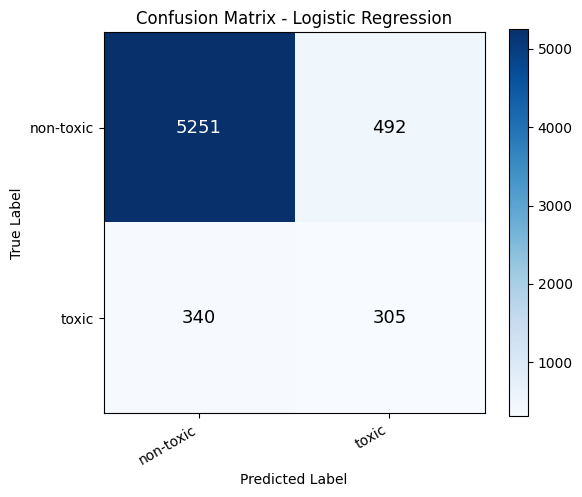

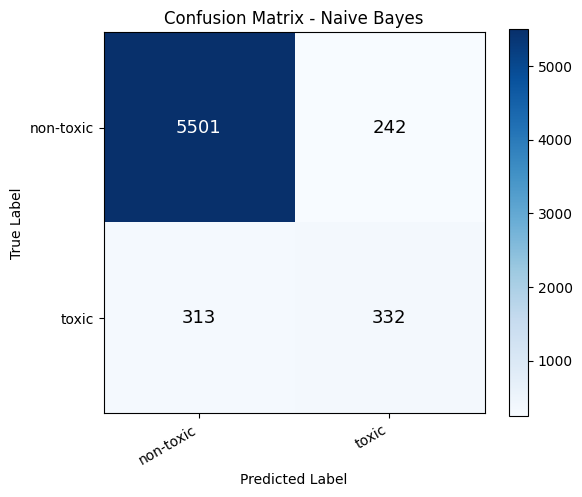

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot confusion matrix from Spark DataFrame predictions.
def plot_confusion_matrix(preds_df, model_name):
    # Convert confusion matrix data to pandas for plotting.
    cm_pdf = (
        preds_df.groupBy("label", "prediction")
        .count()
        .orderBy("label", "prediction")
        .toPandas()
    )
    # Create a 2x2 confusion matrix array.
    cm_array = np.zeros((2, 2), dtype=int)
    for _, row in cm_pdf.iterrows():
        i = int(row["label"])
        j = int(row["prediction"])
        cm_array[i][j] = int(row["count"])
    
    # Plotting the confusion matrix.
    class_names = ["non-toxic", "toxic"]
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_array, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(2)); ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_yticks(range(2)); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"Confusion Matrix - {model_name}")
    
    # Add text annotations.
    thresh = cm_array.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_array[i, j]), ha="center", va="center",
                    color="white" if cm_array[i, j] > thresh else "black", fontsize=13)
    plt.tight_layout()
    plt.show()

# Plot confusion matrices for two example models.
plot_confusion_matrix(predictions_dict["Logistic Regression"], "Logistic Regression")
plot_confusion_matrix(predictions_dict["Naive Bayes"], "Naive Bayes")


## 8. Convert Results to a Local Table for Plotting

Small result tables can be converted locally for plotting.
This does **not** violate the Spark requirement because the ML workflow itself remains in Spark.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
# Convert Spark DataFrame to Pandas for plotting
plot_df = results_df.toPandas()
plot_df


,accuracy,f1,model,precision,recall
0,0.920632,0.902681,GBT Classifier,0.913098,0.920632
1,0.913118,0.910855,Naive Bayes,0.909031,0.913118
2,0.911866,0.902163,Linear SVM,0.898977,0.911866
3,0.869756,0.875747,Logistic Regression,0.882998,0.869756


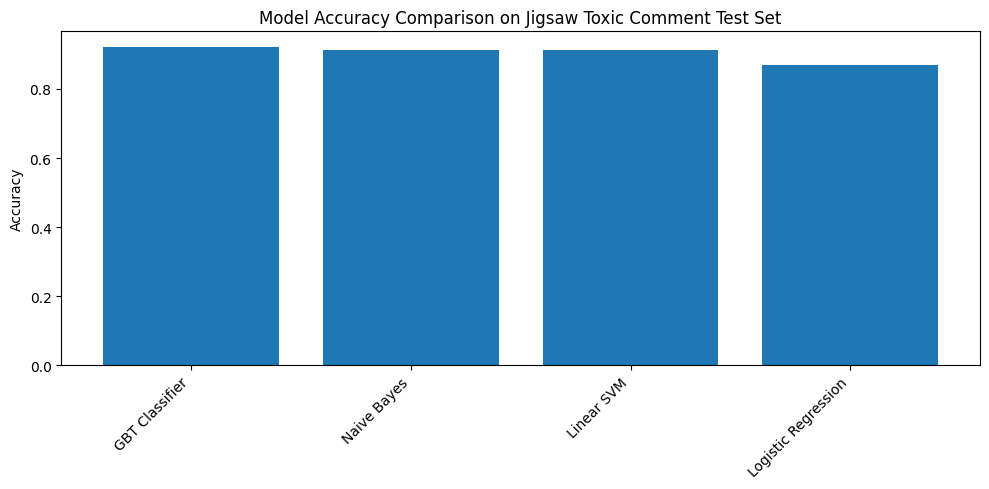

In [14]:
# Simple comparison chart.
plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison on Jigsaw Toxic Comment Test Set")
plt.tight_layout()
plt.show()


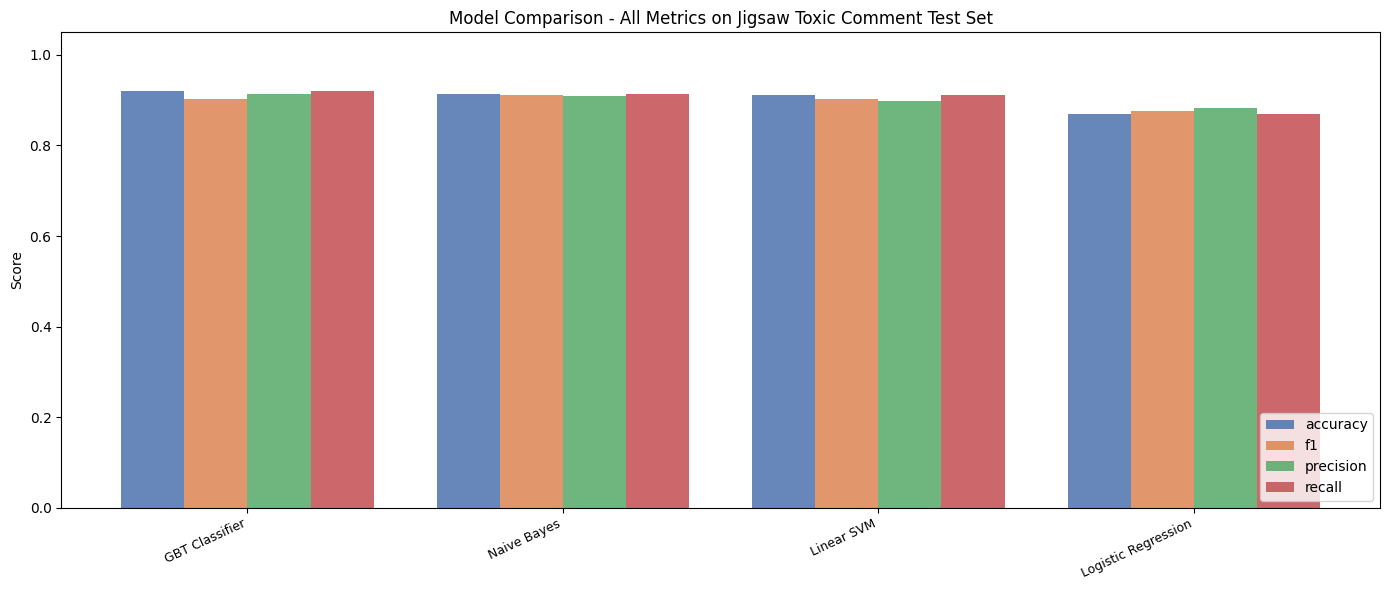

In [15]:
# Grouped bar chart comparing all 4 metrics across all models.
import numpy as np

# Define metrics and colors for the plot.
metrics = ["accuracy", "f1", "precision", "recall"]
model_names = plot_df["model"].tolist()
x = np.arange(len(model_names))
width = 0.2
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(14, 6))
# Create bars for each metric.
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, plot_df[metric], width, label=metric, color=color, alpha=0.85)
# Set x-ticks and labels.
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison - All Metrics on Jigsaw Toxic Comment Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 9. Interpretation Notes for Students

In your notebook and report, explain:
- Which model performed best?
- Whether the results were close or very different
- Why some models may perform better or worse on sparse text features
- How class imbalance affects accuracy, precision, recall, and F1
- Any limitations of converting the original six-label Kaggle task into one binary `any toxic` label

You should not only show numbers; you should also interpret them.


## 10. Required Report Reminder

Your report should summarize:
1. The workflow you used
2. The Spark pipeline components
3. The models you trained
4. The evaluation results
5. Your discussion and conclusions


## 11. Important Reminder About Phase 2

This notebook now uses the Jigsaw toxic comment dataset and can be extended further by training one model per toxicity label or by using Spark NLP-style feature engineering.


## 12. Checklist Before Submission

- [ ] Used Spark DataFrames
- [ ] Used Spark ML Pipeline components
- [ ] Trained at least 6 approved models
- [ ] Reported accuracy, precision, recall, and F1
- [ ] Included confusion matrices for at least 2 models
- [ ] Compared models in a table or figure
- [ ] Wrote clear comments in the notebook
- [ ] Prepared the 3–4 page report
